# **Sentiment Analysis of Amazon Product Reviews using Classical and Transformer-Based Models**

# 1 Introduction

Online shopping platforms like Amazon rely heavily on customer reviews.  
These reviews are written in free text, and there are millions of them, so it is not practical for a human to read and interpret everything. Being able to automatically detect whether a review is positive or negative helps companies monitor product quality, track customer satisfaction, and support recommendation systems.



##1.1 Dataset:

*Kaggle Dataset Link:*
*   Source: Kaggle “Amazon reviews” by Kritanjali Jain - https://www.kaggle.com/datasets/kritanjalijain/amazon-reviews/data

**DATASET DESCRPTION:**

The Amazon reviews polarity dataset is constructed by taking review score 1 and 2 as negative, and 4 and 5 as positive. Samples of score 3 is ignored. In the dataset, class 1 is the negative and class 2 is the positive. Each class has 1,800,000 training samples and 200,000 testing samples.

The files train.csv and test.csv contain all the training samples as comma-separated values.

The CSVs contain polarity, title, text. These 3 columns in them, correspond to class index (1 or 2), review title and review text.


In this project, we use a public Amazon reviews dataset which contains three main fields for each review, we treat this as a binary sentiment classification problem.

- **polarity** - sentiment label provided in the dataset (1 = negative review, 2 = positive review)  
- **title** - short headline of the review  
- **text** - full review written by the customer  


## 1.2 Problem Definition and Goal

The objective of this project is to build and evaluate models for supervised
sentiment classification on Amazon product reviews. The task is to determine
whether a review expresses a **negative** (0) or **positive** (1) sentiment based
solely on its text content.

- **Input:** Combined review text (title + body)
- **Output:** Binary sentiment label (0 = negative, 1 = positive)

To maintain computational feasibility in Google Colab, we work with a 50% random
sample of the original dataset (~1.8M reviews).  

We evaluate models using accuracy, precision, recall, F1-score, confusion matrix,
and ROC-AUC.

This project compares two broad families of pattern-recognition models:

1. **Classical model:** TF-IDF features + Logistic Regression  
2. **Transformer models:** DistilBERT and RoBERTa fine-tuned on the dataset  

The goal is to understand trade-offs between accuracy, efficiency, and
interpretability across these approaches.

## 1.3 Project Flow

The workflow follows this pipeline:

> **Raw Text -> Preprocessing -> Feature Extraction -> Model Training -> Evaluation**

We compare two types of feature representations:

1. **Engineered Features (TF-IDF):** used with Logistic Regression.

2. **Learned Representations (Transformers):**  
   Contextual embeddings learned automatically by DistilBERT and RoBERTa during
   fine-tuning.

This setup allows us to examine how classical and modern models differ in how
they represent text, how separable the classes become, and how their performance
scales with model complexity.

# 2 Load Dataset and Basic Cleaning

## 2.1 Setup and Library Imports

In [ ]:
# Install extra libraries
!pip install wordcloud transformers datasets kaggle --quiet

# Core libraries
import numpy as np
import pandas as pd
import os
import re
import torch

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_fscore_support
)
from sklearn.decomposition import TruncatedSVD,PCA, LatentDirichletAllocation

from sklearn.feature_selection import SelectKBest, chi2

# Transformers (for DistilBERT)
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Transformers (for RoBERTa)
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import warnings
warnings.filterwarnings("ignore")

print("Setup complete.")


Setup complete.


## 2.2 Mount Drive and Load Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
train_path = "/content/drive/MyDrive/pattern /train.csv"
test_path  = "/content/drive/MyDrive/pattern /test.csv"

# The Kaggle dataset structure: polarity, title, text
col_names = ['polarity', 'title', 'text']

df_train_raw = pd.read_csv(
    train_path,
    header=None,
    names=col_names,
    engine="python",
    on_bad_lines="skip"
)

df_test_raw = pd.read_csv(
    test_path,
    header=None,
    names=col_names,
    engine="python",
    on_bad_lines="skip"
)

print("Raw train shape:", df_train_raw.shape)
print("Raw test shape:", df_test_raw.shape)
df_train_raw.head()

Raw train shape: (3600000, 3)
Raw test shape: (400000, 3)


,polarity,title,text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


## 2.3 Basic Cleaning and reducing the dataset

We apply a consistent preprocessing pipeline to both the train and test files:

1. **Remove missing entries** in the label or text fields.  
2. **Keep only valid labels** (1 or 2).  
3. **Convert labels** into a binary sentiment variable:  
   - 1 -> 0 (negative)  
   - 2 -> 1 (positive)  
4. **Merge the title and review body** into a single `review_text` field.  
5. **Normalize text length features** such as word count and character count for
   exploratory analysis.  
6. **Sample 50% of the dataset** (~1.8M reviews) to maintain computational
   feasibility while keeping the distribution unchanged.

In [ ]:
def preprocess_reviews(df, frac=0.5, random_state=42):
    # Drop missing polarity/text
    df = df.dropna(subset=["polarity", "text"]).copy()

    # Keep only valid labels 1 and 2
    df = df[df["polarity"].isin([1, 2])].copy()

    # Map to sentiment 0/1
    # polarity=1 -> negative (0), polarity=2 -> positive (1)
    df["sentiment"] = df["polarity"].map({1: 0, 2: 1})

    # Combine title + text
    df["title"] = df["title"].fillna("")
    df["review_text"] = (df["title"].astype(str) + " " + df["text"].astype(str)).str.strip()

    # Reduce dataset
    if frac is not None and frac < 1.0:
        df = df.sample(frac=frac, random_state=random_state)

    df["word_len"] = df["review_text"].apply(lambda x: len(str(x).split()))
    df["char_len"] = df["review_text"].apply(lambda x: len(str(x)))

    return df


In [ ]:
df_train = preprocess_reviews(df_train_raw, frac=0.5, random_state=42)
df_test  = preprocess_reviews(df_test_raw,  frac=0.5, random_state=123)

print("Processed train:", df_train.shape)
print("Processed test :", df_test.shape)

print(df_train[["polarity", "sentiment", "review_text"]].head())


Processed train: (1800000, 7)
Processed test : (200000, 7)
         polarity  sentiment  \
2079998         1          0   
1443106         1          0   
3463669         2          1   
2914699         1          0   
1603231         1          0   

                                               review_text  
2079998  Expensive Junk This product consists of a piec...  
1443106  Toast too dark Even on the lowest setting, the...  
3463669  Excellent imagery...dumbed down story I enjoye...  
2914699  Are we pretending everyone is married? The aut...  
1603231  Not worth your time Might as well just use a k...  


After preprocessing, each dataset contains:
- Clean binary labels  
- Combined review text  
- Length-based metadata  
- Balanced sentiment proportions  

This prepares the data for downstream tasks such as TF-IDF vectorization,
Transformer tokenization, and model training.

#3 Exploratory Data Analysis (EDA)


Before building the models, we examine the structure and properties of the
preprocessed dataset. Understanding how reviews are distributed, how long they
tend to be, and which words appear frequently helps contextualize the modeling
results and highlights any potential challenges.

## 3.1 Review Length Distribtuions

We compute simple length-based features such as:
- Word count
- Character count

In [ ]:
# Word count
df_train["word_len"] = df_train["review_text"].str.split().str.len()

# Character count
df_train["char_len"] = df_train["review_text"].str.len()

print("Word length summary:\n", df_train["word_len"].describe())
print("\nCharacter length summary:\n", df_train["char_len"].describe())


Word length summary:
 count    1.800000e+06
mean     7.846100e+01
std      4.284011e+01
min      2.000000e+00
25%      4.200000e+01
50%      7.000000e+01
75%      1.080000e+02
max      2.570000e+02
Name: word_len, dtype: float64

Character length summary:
 count    1.800000e+06
mean     4.305249e+02
std      2.376048e+02
min      7.100000e+01
25%      2.300000e+02
50%      3.820000e+02
75%      5.940000e+02
max      1.014000e+03
Name: char_len, dtype: float64


## 3.2 Distribution Plot of Review Length

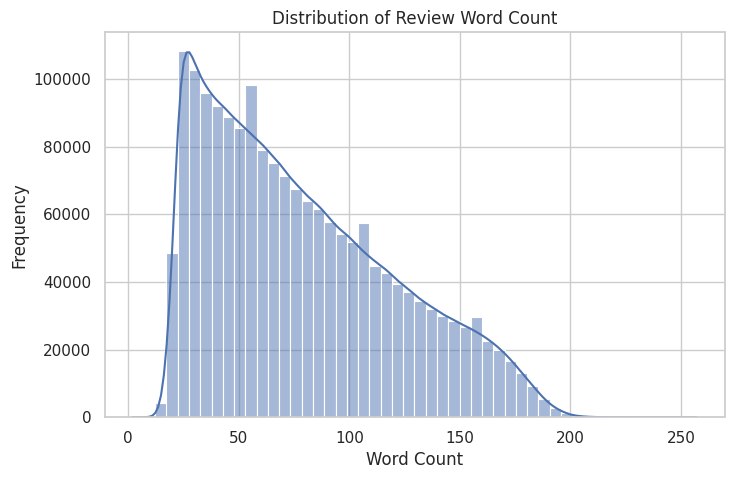

In [ ]:
sns.histplot(df_train["word_len"], bins=50, kde=True)
plt.title("Distribution of Review Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


## 3.3 Sentiment Distribution

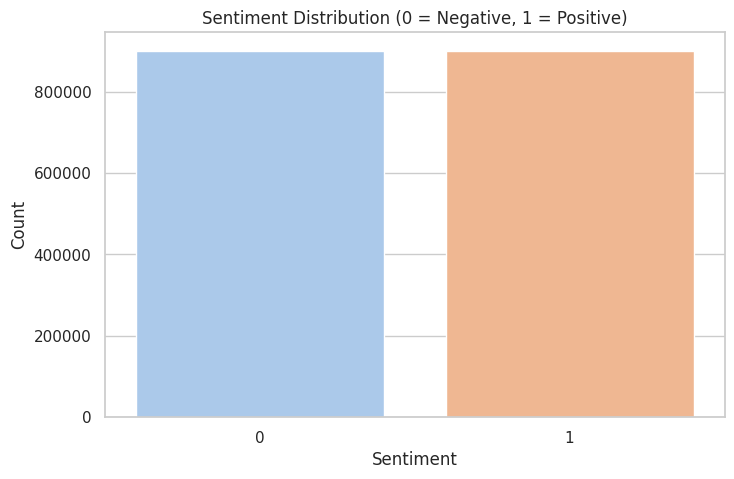

In [ ]:
sns.countplot(data=df_train, x="sentiment", palette="pastel")
plt.title("Sentiment Distribution (0 = Negative, 1 = Positive)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


This shows that the dataset is naturally well balanced between negative (0) and positive (1)
labels, which is desirable for supervised classification. A balanced dataset
ensures that accuracy, precision, and recall are meaningful and reduces the need
for oversampling or reweighting strategies.

## 3.4 WordCloud for each Sentiment

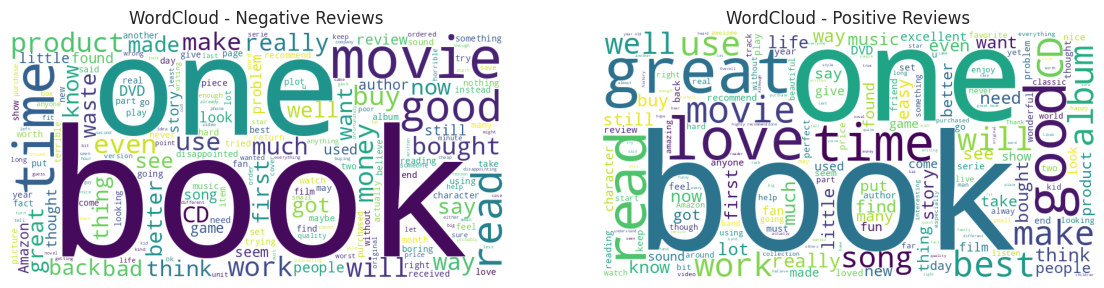

In [ ]:
sample_neg = df_train[df_train["sentiment"] == 0].sample(50000, random_state=42)
sample_pos = df_train[df_train["sentiment"] == 1].sample(50000, random_state=42)

neg_text = " ".join(sample_neg["review_text"].tolist())
pos_text = " ".join(sample_pos["review_text"].tolist())

wc_neg = WordCloud(width=800, height=400, background_color="white").generate(neg_text)
wc_pos = WordCloud(width=800, height=400, background_color="white").generate(pos_text)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(wc_neg)
plt.axis("off")
plt.title("WordCloud - Negative Reviews")

plt.subplot(1,2,2)
plt.imshow(wc_pos)
plt.axis("off")
plt.title("WordCloud - Positive Reviews")
plt.show()


Word clouds provide a high-level view of frequently occurring terms in positive
and negative reviews. As expected for a diverse Amazon dataset, the most common
words tend to be **topic-related** (e.g., “book”, “movie”, “story”) rather than
sentiment-bearing adjectives.

This suggests that more sophisticated text features
(TF-IDF or Transformers) are needed for effective classification.

## 3.5 Correlation of numeric features

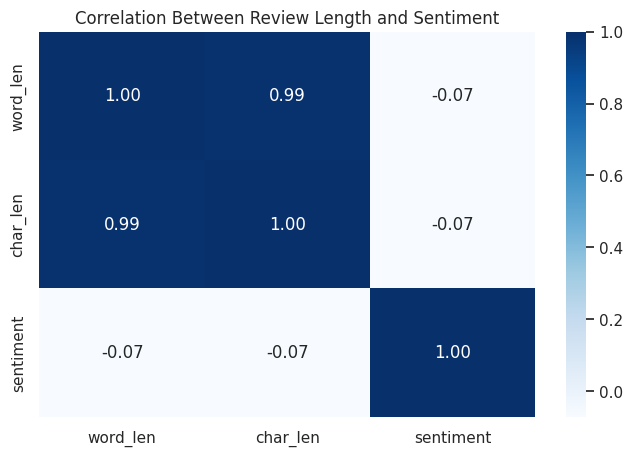

In [ ]:
numeric_features = ["word_len", "char_len"]

corr = df_train[numeric_features + ["sentiment"]].corr()

sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Between Review Length and Sentiment")
plt.show()


The correlation matrix shows that review length (in words or characters) has almost no relationship with sentiment (correlation ~ -0.07). This indicates that customers write both positive and negative reviews of varying lengths, so length is not a strong predictor of sentiment. Therefore, meaningful sentiment patterns must come from the actual text content rather than simple numerical features.


## 3.6 Review Length vs Sentiment

We also plot the review word count against sentiment to see whether one class tends to
have longer or shorter reviews on average.



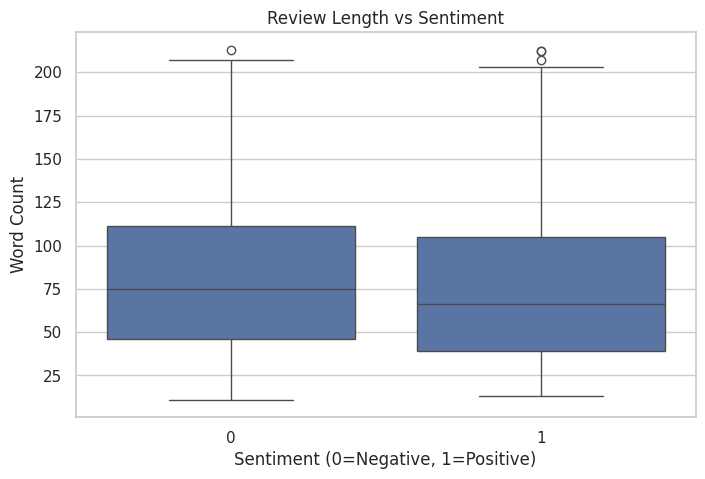

In [ ]:
sns.boxplot(data=df_train.sample(50000), x="sentiment", y="word_len")
plt.title("Review Length vs Sentiment")
plt.xlabel("Sentiment (0=Negative, 1=Positive)")
plt.ylabel("Word Count")
plt.show()


The boxplot shows that the word-count distributions for negative and positive
reviews are very similar, with only minor differences in median and spread.
This confirms that review length is not a strong driver of sentiment and agrees
with the near-zero correlations observed earlier.


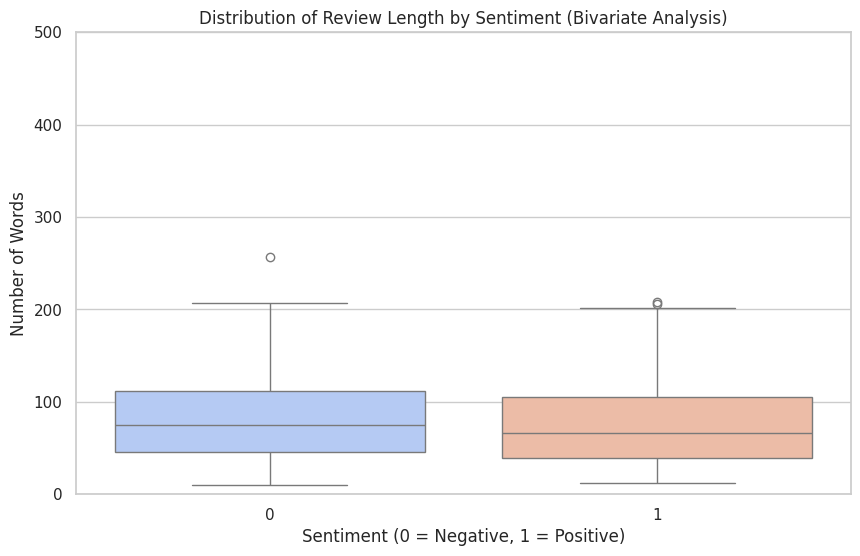

In [ ]:
if 'word_count' not in df_train.columns:
    df_train['word_count'] = df_train['review_text'].apply(lambda x: len(str(x).split()))


plot_sample = df_train.sample(50000, random_state=42)

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='sentiment',
    y='word_count',
    data=plot_sample,
    palette='coolwarm'
)

plt.title('Distribution of Review Length by Sentiment (Bivariate Analysis)')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Number of Words')
plt.ylim(0, 500)
plt.show()


To further investigate potential structural patterns, we plot review length
distributions grouped by sentiment. The overlap between classes visually confirms
the earlier findings: **length is not a discriminative feature** for sentiment.

## 3.7 Summary of EDA Findings

- The dataset is balanced and suitable for supervised learning.
- Review length does **not** strongly predict sentiment.
- High-frequency terms reflect product categories rather than polarity.
- Sentiment-bearing words are sparse, requiring feature extraction techniques
  such as TF-IDF or contextual embeddings from Transformers.
- No major outliers require removal, and the distributions are stable enough for
  modeling.


#4 Preprocessing

Train/Validation Split, TF-IDF, Feature Selection, and SVD/PCA Visualization


* Data preparation
* Feature engineering
* Dimensionality reduction (PCA/SVD)
* Preparing data for model training

## 4.1 Train/Validation Split, Test

In [ ]:
X_train_full = df_train["review_text"]
y_train_full = df_train["sentiment"]

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

X_test = df_test["review_text"]
y_test = df_test["sentiment"]

print("Train size:", len(X_train))
print("Val size  :", len(X_val))
print("Test size :", len(X_test))


Train size: 1440000
Val size  : 360000
Test size : 200000


## 4.2 TF-IDF Vectorization

We begin by transforming each review into a vector of weighted word features
using **Term Frequency-Inverse Document Frequency (TF-IDF)**.  
This representation downweights extremely common words and highlights terms that
are informative for distinguishing sentiment classes.

Key configuration choices:
- **Maximum features:** 50,000  
- **n-grams:** unigrams and bigrams  
- **Stopwords:** English  
- **Minimum document frequency:** 5 occurrences (Ignore extremely rare words)  

In [ ]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shapes:")
print("Train:", X_train_tfidf.shape)
print("Val  :", X_val_tfidf.shape)
print("Test :", X_test_tfidf.shape)


TF-IDF shapes:
Train: (1440000, 50000)
Val  : (360000, 50000)
Test : (200000, 50000)


## 4.3 Chi-Square Feature Selection


The TF-IDF matrix contains 50,000 features. Chi-Square feature selection reduces this to 20,000 by keeping only the terms most correlated with sentiment.  
This leads to:
- Faster training  
- Less noise  
- Better generalization  


In [ ]:
selector = SelectKBest(chi2, k=20000)
X_train_fs = selector.fit_transform(X_train_tfidf, y_train)
X_val_fs   = selector.transform(X_val_tfidf)
X_test_fs  = selector.transform(X_test_tfidf)

print("After feature selection:")
print("Train:", X_train_fs.shape)
print("Val  :", X_val_fs.shape)
print("Test :", X_test_fs.shape)

After feature selection:
Train: (1440000, 20000)
Val  : (360000, 20000)
Test : (200000, 20000)


## 4.4 Dimensionality Reduction: SVD

TruncatedSVD - perfroms PCA_like reduction

In [ ]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_train_2d = svd.fit_transform(X_train_fs)

print("Explained variance ratio:", svd.explained_variance_ratio_)


Explained variance ratio: [0.00237092 0.00612316]


## 4.5 PCA style visualization (Sentiment in 2D)

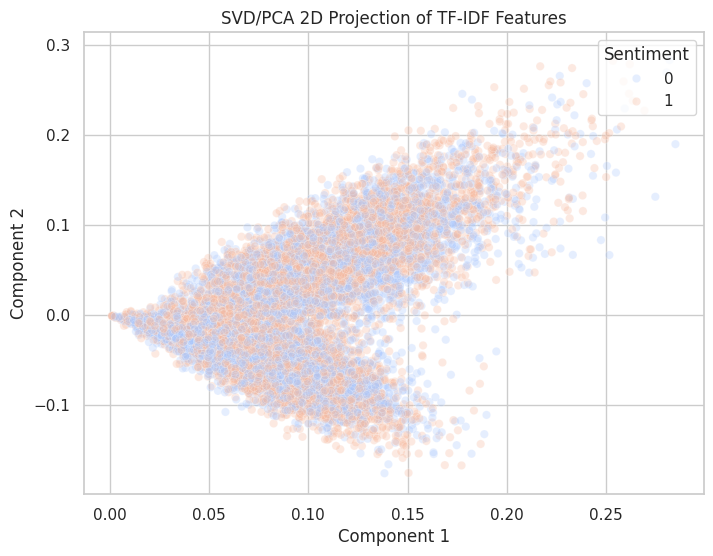

In [ ]:
vis_idx = np.random.choice(range(X_train_2d.shape[0]), size=20000, replace=False)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_train_2d[vis_idx, 0],
    y=X_train_2d[vis_idx, 1],
    hue=y_train.iloc[vis_idx],
    palette="coolwarm",
    alpha=0.3
)
plt.title("SVD/PCA 2D Projection of TF-IDF Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Sentiment", loc="upper right")
plt.show()


The 2D SVD projection shows substantial overlap between positive and negative reviews.
This is expected because sentiment signals are distributed across thousands of
TF-IDF dimensions, and reducing the data to two components cannot capture the
complex structure of the text. The visualization confirms that dimensionality
reduction is useful for understanding overall structure, but not sufficient for
classification by itself.




# 5 Model Training: Logistic Regression
* Simple
* Fast
* Strong baseline
* Excellent for TF-IDF features


We train Logistic Regression on the chi-square-filtered TF-IDF features with:

- Maximum iterations: 300  
- L2 regularization  
- Multi-threaded optimization (`n_jobs = -1`)  

In [ ]:
log_reg = LogisticRegression(
    max_iter=300,
    n_jobs=-1,
)

log_reg.fit(X_train_fs, y_train)

print("Model training completed.")


Model training completed.


##5.1 Validation Performance

In [ ]:
# Validation evaluation
y_val_pred = log_reg.predict(X_val_fs)
y_val_prob = log_reg.predict_proba(X_val_fs)[:, 1]

val_acc = accuracy_score(y_val, y_val_pred)
print("Validation accuracy:", val_acc)
print("\nValidation classification report:\n")
print(classification_report(y_val, y_val_pred))

Validation accuracy: 0.906275

Validation classification report:

              precision    recall  f1-score   support

           0       0.91      0.90      0.91    180157
           1       0.90      0.91      0.91    179843

    accuracy                           0.91    360000
   macro avg       0.91      0.91      0.91    360000
weighted avg       0.91      0.91      0.91    360000



## 5.2 Test Performance/Evaluation

In [ ]:
y_test_pred = log_reg.predict(X_test_fs)
y_test_prob = log_reg.predict_proba(X_test_fs)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
print("Test accuracy:", test_acc)
print("\nTest classification report:\n")
print(classification_report(y_test, y_test_pred))

Test accuracy: 0.90643

Test classification report:

              precision    recall  f1-score   support

           0       0.91      0.90      0.91    100007
           1       0.90      0.91      0.91     99993

    accuracy                           0.91    200000
   macro avg       0.91      0.91      0.91    200000
weighted avg       0.91      0.91      0.91    200000



###5.2.1 Classification report (Logisitc Regrssion)

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.90      0.91    100007
           1       0.90      0.91      0.91     99993

    accuracy                           0.91    200000
   macro avg       0.91      0.91      0.91    200000
weighted avg       0.91      0.91      0.91    200000



### 5.2.2 Confusion matrix (Logisitc Regrssion)

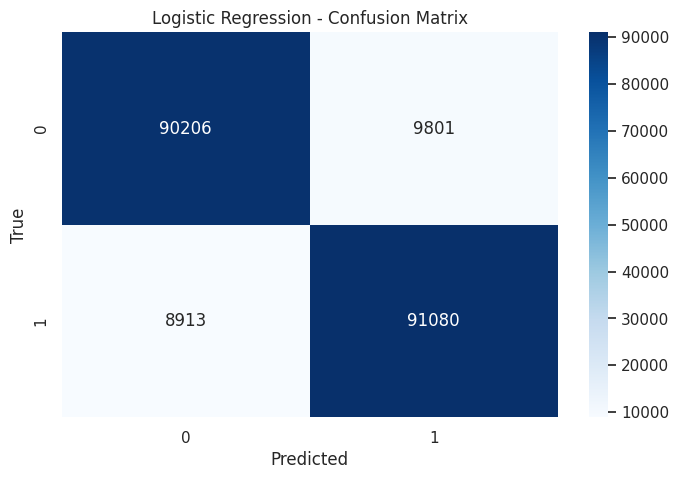

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


### 5.2.3 ROC Curve (Logisitc Regrssion)

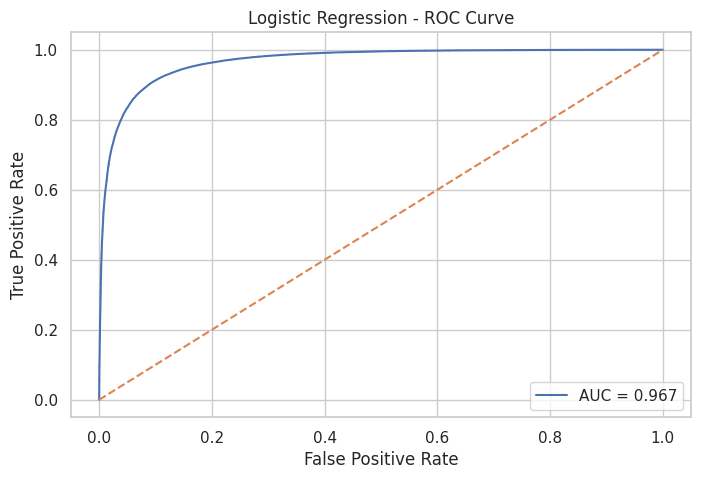

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend()
plt.show()


## 5.3 Summary of Logistic Regression

- The model achieves an accuracy of **90.6%** on the test set,
with precision and recall around **0.90-0.91** for both negative and positive
classes. This indicates that the model performs well and does not strongly favor
one class over the other.

- The confusion matrix shows comparable numbers of false positives and false
negatives and a large number of correct predictions on the diagonal.

- The ROC curve has an AUC well above 0.9, meaning the model is very effective at ranking positive reviews higher than negative ones.
- However, the model struggles with nuanced sentiment, sarcasm, mixed tone, and
  multi-sentence reasoning.
- These limitations motivate the use of high-capacity Transformer models.


## 5.4 Interpretation of Logistic Regression - Feature Importance: Most Informative Words




In [ ]:
# Recovering the feature names after TF-IDF and chi-square selection
all_features = np.array(tfidf.get_feature_names_out())
selected_mask = selector.get_support()
selected_features = all_features[selected_mask]

# Logistic Regression has one coefficient per feature
coefs = log_reg.coef_[0]

# Top 20 most positive and most negative features
top_pos_idx = np.argsort(coefs)[-20:]
top_neg_idx = np.argsort(coefs)[:20]

print("Top 20 words most associated with POSITIVE sentiment:")
for feat, c in zip(selected_features[top_pos_idx], coefs[top_pos_idx]):
    print(f"{feat:20s}  coef={c:.3f}")

print("\nTop 20 words most associated with NEGATIVE sentiment:")
for feat, c in zip(selected_features[top_neg_idx], coefs[top_neg_idx]):
    print(f"{feat:20s}  coef={c:.3f}")


Top 20 words most associated with POSITIVE sentiment:
love                  coef=8.295
fantastic             coef=8.355
gem                   coef=8.370
awsome                coef=8.483
downside              coef=8.568
complaint             coef=8.584
does supposed         coef=8.974
wonderful             coef=9.137
superb                coef=9.251
outstanding           coef=9.290
highly recommend      coef=10.262
refreshing            coef=10.352
best                  coef=10.582
amazing               coef=10.611
better expected       coef=10.826
perfect               coef=11.250
awesome               coef=11.887
great                 coef=14.570
won disappointed      coef=14.774
excellent             coef=15.343

Top 20 words most associated with NEGATIVE sentiment:
disappointing         coef=-19.111
worst                 coef=-16.121
disappointment        coef=-15.291
disappointed          coef=-14.234
boring                coef=-14.158
poorly                coef=-13.418
poor       

The most positive coefficients correspond to words and phrases strongly
associated with positive sentiment (e.g. "excellent", "love", "highly
recommended"), while the most negative coefficients correspond to terms such as
"terrible", "waste", "poor", etc.

This directly answers which variables (features) are most important for the
classifier: words with large positive or negative coefficients have the greatest
impact on the predicted sentiment.


## 5.5  Error Analysis: Misclassified Reviews

To better understand the model's behavior, we inspect reviews that the classifier
misclassified.
We compare the model’s predictions with the true validation labels and extract:

- **False Positives (FP):** Negative reviews predicted as positive  
- **False Negatives (FN):** Positive reviews predicted as negative

This helps reveal patterns such as mixed sentiment, ambiguous
language, or cases where the true label is itself debatable.


In [ ]:
val_df = pd.DataFrame({
    "review_text": X_val.reset_index(drop=True),
    "true_label": y_val.reset_index(drop=True),
    "pred_label": y_val_pred,
    "pred_prob_pos": y_val_prob  # probability of positive class
})

# Identify misclassified examples on validation
mis_df = val_df[val_df["true_label"] != val_df["pred_label"]]

print("Total validation samples:", len(val_df))
print("Misclassified samples:", len(mis_df))
print("Misclassification rate:", len(mis_df) / len(val_df))

# False positives: predicted positive but actually negative
fp = mis_df[(mis_df["true_label"] == 0) & (mis_df["pred_label"] == 1)].sample(5, random_state=42)

# False negatives: predicted negative but actually positive
fn = mis_df[(mis_df["true_label"] == 1) & (mis_df["pred_label"] == 0)].sample(5, random_state=42)



Total validation samples: 360000
Misclassified samples: 33741
Misclassification rate: 0.093725


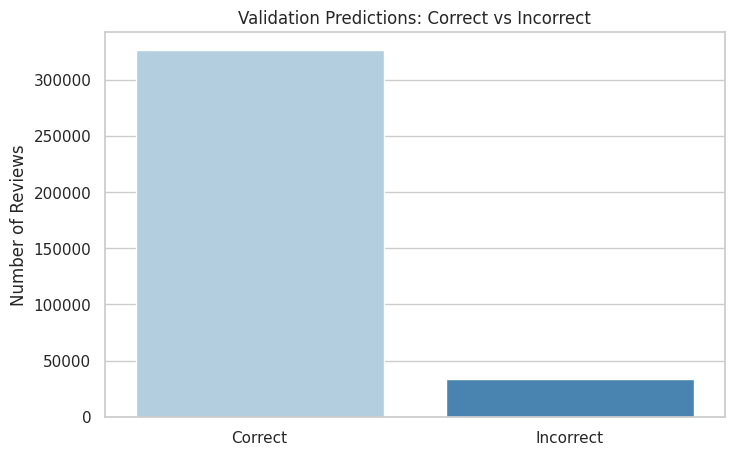

In [ ]:
correct = len(val_df) - len(mis_df)
incorrect = len(mis_df)

sns.barplot(x=["Correct", "Incorrect"], y=[correct, incorrect], palette="Blues")
plt.title("Validation Predictions: Correct vs Incorrect")
plt.ylabel("Number of Reviews")
plt.show()


The majority of test reviews are correctly classified, with roughly 9-10% misclassified, consistent with the accuracy metric.

### 5.5.1 Key Insights from Error Analysis

Common patterns among misclassified samples include:
- **Mixed or neutral sentiment** (e.g., “I loved the show, but this season is weak.”)
- **Sarcasm or humor**, which linear models cannot detect reliably
- **Domain-specific language**, such as technical product descriptions
- **Very short reviews** lacking sentiment cues

These insights help diagnose model limitations and suggest where deep learning models can offer improvements.


## 5.6 Local Explainability - LIME-style word relevance

To understand individual predictions, we use LIME (Local Interpretable Model-agnostic
Explanations). LIME perturbs the text around a given review and learns a simple
local model that approximates the classifier's behavior, highlighting the most
influential words for that specific prediction.


In [ ]:
!pip install lime --quiet

from lime.lime_text import LimeTextExplainer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Wrapper for LIME: takes raw texts and returns predicted probabilities using our LogReg model
class_names = ["negative", "positive"]

def predict_proba_lime(texts):
    X = tfidf.transform(texts)
    X = selector.transform(X)
    return log_reg.predict_proba(X)

explainer = LimeTextExplainer(class_names=class_names)

example_row = mis_df.sample(1, random_state=0).iloc[0]
example_text = example_row["review_text"]
true_label   = example_row["true_label"]
pred_label   = example_row["pred_label"]

print("True label:", true_label, " Predicted label:", pred_label)
print("\nReview text:\n", example_text[:800], ".\n")

exp = explainer.explain_instance(
    example_text,
    predict_proba_lime,
    num_features=10,
    labels=[0, 1]
)

print("\nTop contributing words for positive class (label=1):")
for word, weight in exp.as_list(label=1):
    print(f"{word:20s} weight={weight:.3f}")

print("\nTop contributing words for negative class (label=0):")
for word, weight in exp.as_list(label=0):
    print(f"{word:20s} weight={weight:.3f}")


True label: 0  Predicted label: 1

Review text:
 a question can anybody tell me how many Episodes in these 4 discs ?can anybody tell me how many Episodes in these 4 discs ?can anybody tell me how many Episodes in these 4 discs ?can anybody tell me how many Episodes in these 4 discs ?can anybody tell me how many Episodes in these 4 discs ? .


Top contributing words for positive class (label=1):
Episodes             weight=0.075
tell                 weight=0.051
anybody              weight=-0.028
discs                weight=0.008
question             weight=-0.001
me                   weight=-0.000
a                    weight=0.000
these                weight=0.000
how                  weight=0.000
many                 weight=-0.000

Top contributing words for negative class (label=0):
Episodes             weight=-0.075
tell                 weight=-0.051
anybody              weight=0.028
discs                weight=-0.008
question             weight=0.001
me                   weight=0.0

In [ ]:
exp.show_in_notebook(text=example_text)

The LIME visualization highlights the same words with small contributions, confirming that this review provides very weak sentiment cues.

This confirms that logistic regression relies heavily on surface-level word associations and struggles when sentiment-bearing words are absent.


# 6 Topic Modeling of Review Themes

To explore what people talk about in different sentiment groups, we apply a
simple topic model (Latent Dirichlet Allocation, LDA) on a subset of negative
and positive reviews. This helps identify common themes such as books, movies,
electronics, etc.

LDA reveals that both positive and negative reviews discuss common product categories (books, movies, electronics).  
This reinforces the need for models that capture semantic sentiment cues, not topical categories.



In [ ]:
neg_sample = df_train[df_train["sentiment"] == 0]["review_text"].sample(20000, random_state=42)
pos_sample = df_train[df_train["sentiment"] == 1]["review_text"].sample(20000, random_state=42)

vectorizer = CountVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=10
)

def fit_lda(text_series, n_topics=5):
    X_counts = vectorizer.fit_transform(text_series)

    lda_model = LatentDirichletAllocation(
        n_components=n_topics,
        learning_method="batch",
        random_state=42,
        n_jobs=-1
    )
    lda_model.fit(X_counts)

    feature_names = np.array(vectorizer.get_feature_names_out())
    return lda_model, feature_names

lda_neg, feature_names_neg = fit_lda(neg_sample, n_topics=5)
lda_pos, feature_names_pos = fit_lda(pos_sample, n_topics=5)


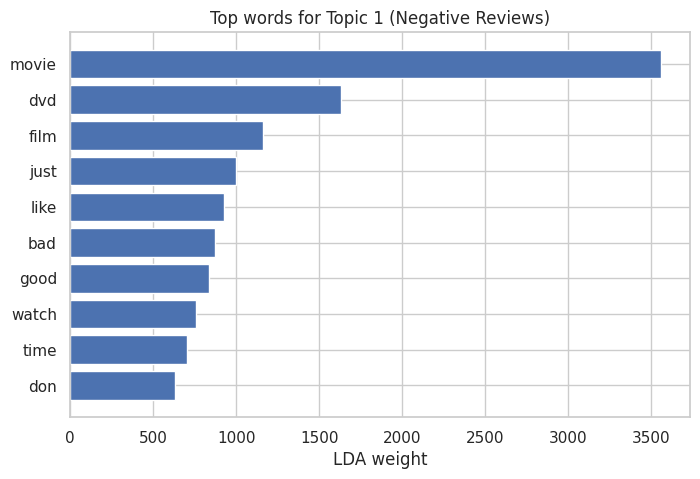

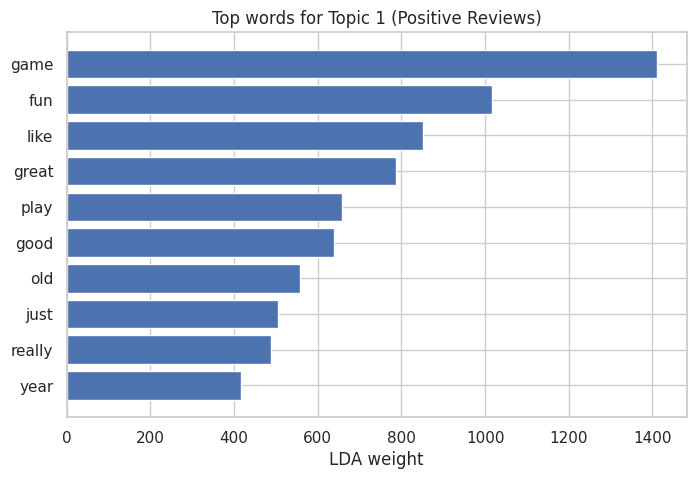

In [ ]:
def plot_topic(lda_model, feature_names, topic_idx, label="Negative"):
    topic = lda_model.components_[topic_idx]
    top_idx = topic.argsort()[-10:]
    top_words = feature_names[top_idx]
    top_weights = topic[top_idx]

    plt.barh(top_words, top_weights)
    plt.title(f"Top words for Topic {topic_idx+1} ({label} Reviews)")
    plt.xlabel("LDA weight")
    plt.show()

plot_topic(lda_neg, feature_names_neg, 0, "Negative")
plot_topic(lda_pos, feature_names_pos, 0, "Positive")


# 7 Transformer Model: DistilBERT on a Subset

To compare our classical TF-IDF + Logistic Regression classifier with a modern
deep learning approach, we fine-tune a pre-trained transformer model
(**DistilBERT**) on a smaller subset of the same Amazon reviews.

DistilBERT is a distilled (smaller and faster) version of BERT that has been
pre-trained on large amounts of text. By fine-tuning it on our sentiment labels,
we can see how much performance gain we obtain compared to the simpler
Logistic Regression baseline.


In [ ]:
df_bert = df_train[["review_text", "sentiment"]].sample(100000, random_state=42)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_bert["review_text"].tolist(),
    df_bert["sentiment"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_bert["sentiment"]
)

test_texts  = df_test["review_text"].tolist()
test_labels = df_test["sentiment"].tolist()

print("BERT train size:", len(train_texts))
print("BERT val size  :", len(val_texts))
print("BERT test size :", len(test_texts))


BERT train size: 80000
BERT val size  : 20000
BERT test size : 200000


In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

MAX_LEN = 128

def tokenize_batch(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": train_texts,
    "labels": train_labels
})

val_dataset = Dataset.from_dict({
    "text": val_texts,
    "labels": val_labels
})

test_dataset = Dataset.from_dict({
    "text": test_texts,
    "labels": test_labels
})

def encode_batch(batch):
    enc = tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )
    enc["labels"] = batch["labels"]
    return enc

train_dataset_enc = train_dataset.map(encode_batch, batched=True)
val_dataset_enc   = val_dataset.map(encode_batch, batched=True)
test_dataset_enc  = test_dataset.map(encode_batch, batched=True)

train_dataset_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])


Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

In [ ]:
!pip install --upgrade transformers --quiet


In [ ]:
model_bert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

os.environ["WANDB_DISABLED"] = "true"

training_args = TrainingArguments(
    output_dir="./bert_results",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=200,
    logging_dir="./bert_logs"
)


trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset_enc,
    eval_dataset=val_dataset_enc,
    compute_metrics=compute_metrics
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


##7.1 Training

In [ ]:
trainer.train()

Step,Training Loss
200,0.474500
400,0.267300
600,0.278800
800,0.239700
1000,0.235500
1200,0.233400
1400,0.204500
1600,0.211500
1800,0.218800
2000,0.202400


TrainOutput(global_step=5000, training_loss=0.20582889099121093, metrics={'train_runtime': 420.0476, 'train_samples_per_second': 190.455, 'train_steps_per_second': 11.903, 'total_flos': 2649347973120000.0, 'train_loss': 0.20582889099121093, 'epoch': 1.0})

## 7.2 Validation Performance

In [ ]:
val_results = trainer.evaluate(val_dataset_enc)
print("Validation metrics:", val_results)


Validation metrics: {'eval_loss': 0.15911713242530823, 'eval_accuracy': 0.94495, 'eval_precision': 0.9526826775677056, 'eval_recall': 0.9359437751004016, 'eval_f1': 0.9442390478602177, 'eval_runtime': 32.2767, 'eval_samples_per_second': 619.642, 'eval_steps_per_second': 19.364, 'epoch': 1.0}


## 7.3 Test Performance

In [ ]:
test_results = trainer.evaluate(test_dataset_enc)
print("Test metrics:", test_results)


Test metrics: {'eval_loss': 0.1544133424758911, 'eval_accuracy': 0.94702, 'eval_precision': 0.9528126994418161, 'eval_recall': 0.9406158431090176, 'eval_f1': 0.9466749871669703, 'eval_runtime': 323.6264, 'eval_samples_per_second': 617.997, 'eval_steps_per_second': 19.312, 'epoch': 1.0}


### 7.3.1 Classification Report (DistillBERT)

In [ ]:
preds_output = trainer.predict(test_dataset_enc)
logits = preds_output.predictions
bert_preds = np.argmax(logits, axis=-1)

print(classification_report(test_labels, bert_preds, digits=4))


              precision    recall  f1-score   support

           0     0.9414    0.9534    0.9474    100007
           1     0.9528    0.9406    0.9467     99993

    accuracy                         0.9470    200000
   macro avg     0.9471    0.9470    0.9470    200000
weighted avg     0.9471    0.9470    0.9470    200000



### 7.3.2 Confusion Matrix (DistillBERT)

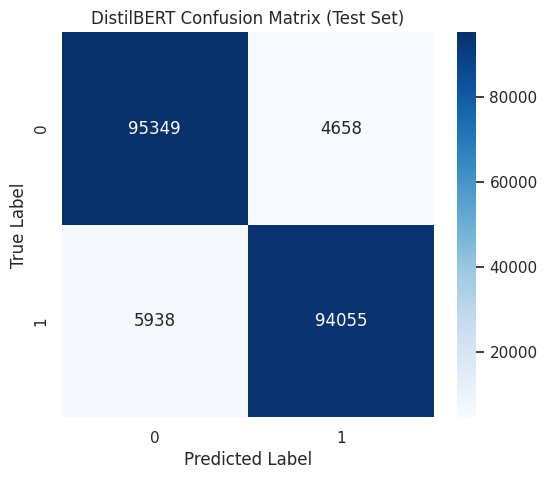

In [ ]:
cm_bert = confusion_matrix(test_labels, bert_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Blues")
plt.title("DistilBERT Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### 7.3.3 ROC Curve (DistillBERT)

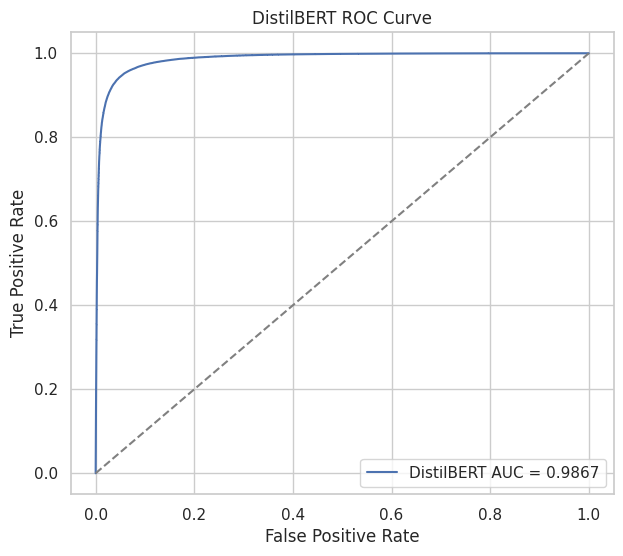

AUC: 0.9866570356346196


In [ ]:
# Convert logits → positive class probability using softmax
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1).numpy()
bert_prob_pos = probs[:, 1]

fpr, tpr, thresholds = roc_curve(test_labels, bert_prob_pos)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"DistilBERT AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DistilBERT ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("AUC:", roc_auc)


## 7.4 Visualization of DistilBERT Feature Space

To better understand how DistilBERT represents reviews, we extract the
embedding of the first token for a subset of
test examples and project these vectors down to two dimensions using PCA. We
then color the points by sentiment label to see whether positive and negative
reviews form distinguishable clusters in the learned feature space.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)
model_bert.eval()

vis_n = 2000
vis_texts = test_texts[:vis_n]
vis_labels = np.array(test_labels[:vis_n])

# Tokenize in batches
batch_size = 64
all_embeddings = []

with torch.no_grad():
    for i in range(0, vis_n, batch_size):
        batch_texts = vis_texts[i:i+batch_size]
        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        ).to(device)

        hidden_states = model_bert.distilbert(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"]
        ).last_hidden_state


        cls_embeddings = hidden_states[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu())

# Stack all batches into one array
all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
all_embeddings.shape


(2000, 768)

### 7.4.1 PCA style visualization (Sentiment in 2D)

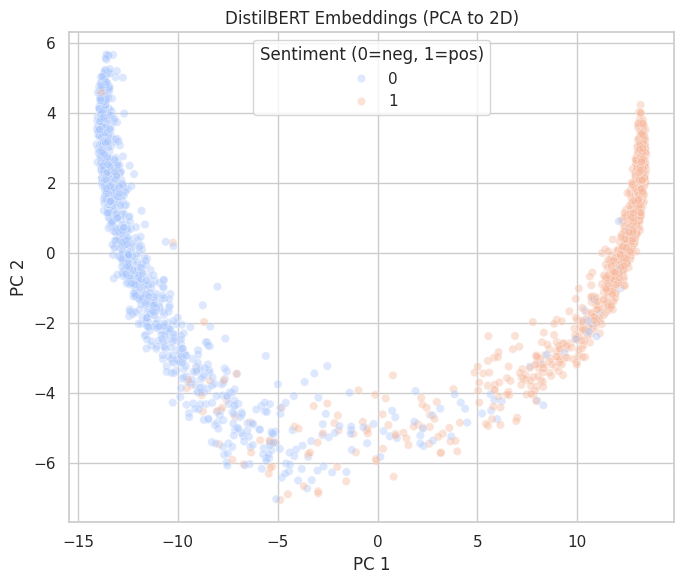

In [ ]:
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(all_embeddings)

plt.figure(figsize=(7,6))
sns.scatterplot(
    x=emb_2d[:, 0],
    y=emb_2d[:, 1],
    hue=vis_labels,
    palette="coolwarm",
    alpha=0.4
)
plt.title("DistilBERT Embeddings (PCA to 2D)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Sentiment (0=neg, 1=pos)")
plt.tight_layout()
plt.show()


In [ ]:
def plot_attention_heatmap(model, tokenizer, text,
                           layer: int = -1,
                           head: int | None = None,
                           max_tokens: int = 40,
                           title_prefix: str = ""):

    model.eval()

    # Tokenize
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_tokens,
        padding=False
    ).to(device)

    with torch.no_grad():
        outputs = model(**enc, output_attentions=True)

    attentions = outputs.attentions
    layer_att = attentions[layer][0]   # (num_heads, seq_len, seq_len)

    if head is None:
        att_matrix = layer_att.mean(dim=0).cpu().numpy()
        head_info = " (avg heads)"
    else:
        att_matrix = layer_att[head].cpu().numpy()
        head_info = f" (head {head})"

    # Token labels
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    tokens = tokens[:max_tokens]
    seq_len = len(tokens)
    att_matrix = att_matrix[:seq_len, :seq_len]

    plt.figure(figsize=(min(0.6 * seq_len, 12), min(0.6 * seq_len, 12)))
    sns.heatmap(
        att_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis"
    )

    # Rotate axis labels for readability
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.xlabel("Tokens Being Attended To (Columns)")
    plt.ylabel("Tokens Paying Attention (Rows)")

    plt.title(f"{title_prefix} Attention Heatmap{head_info}\nLayer {layer}")
    plt.tight_layout()
    plt.show()


TEXT: I thought I was getting a book I thought that I would be reviving a book instead I got a unbound three hole punched hot mess. I could hardly focus on what the book even said.


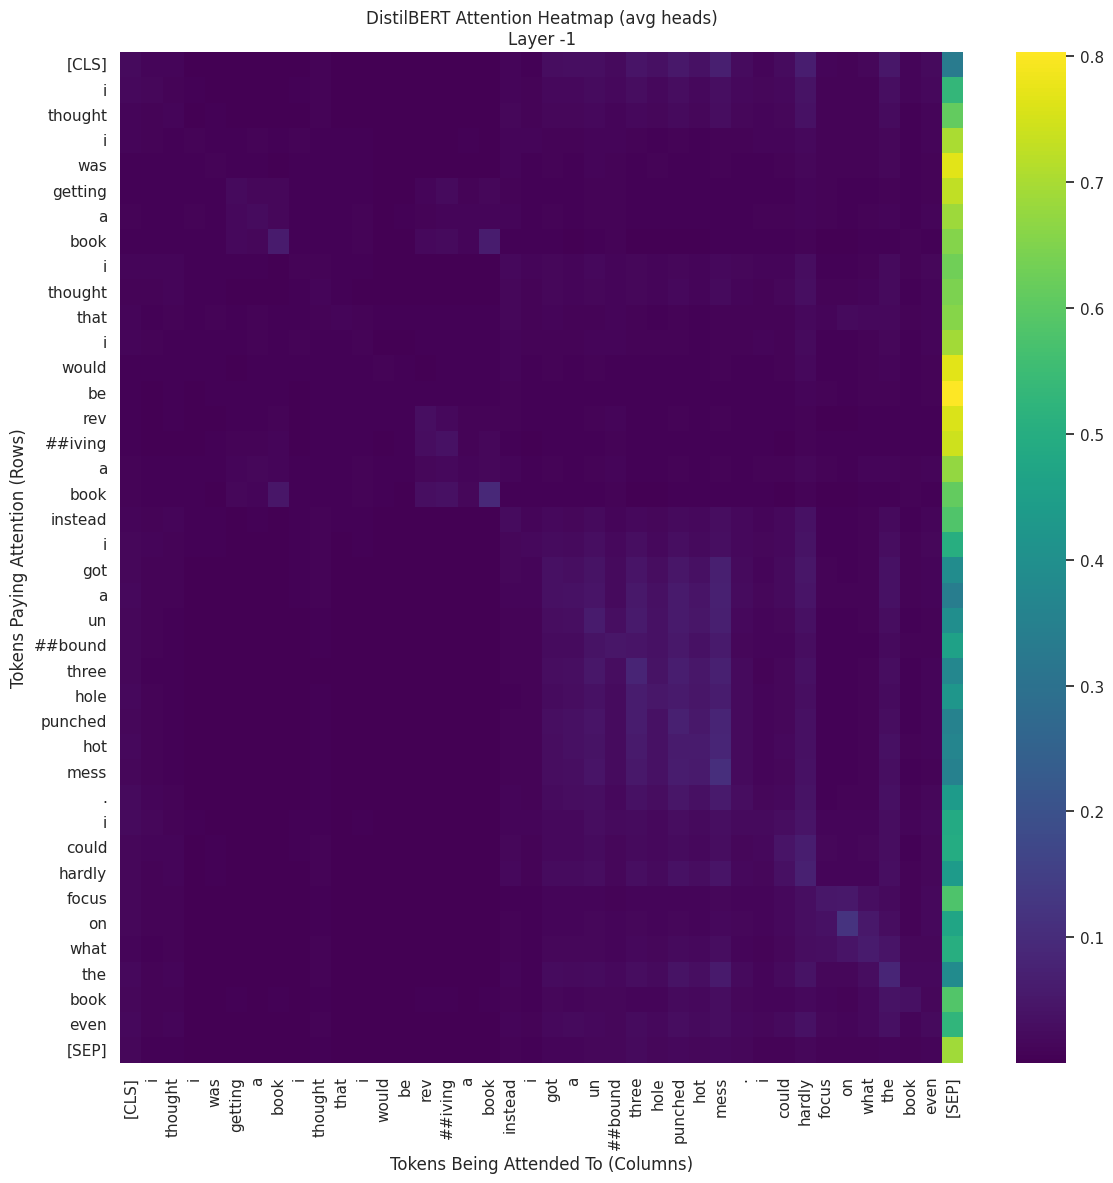

In [ ]:
example_text = test_texts[0]
print("TEXT:", example_text)

# DistilBERT
plot_attention_heatmap(
    model=model_bert,
    tokenizer=tokenizer,
    text=example_text,
    layer=-1,
    head=None,
    max_tokens=40,
    title_prefix="DistilBERT"
)


## 7.5 DistilBERT Performance Summary


DistilBERT significantly outperforms the classical baseline by leveraging
contextual understanding of language. It captures:

- Negation ("not good", "not worth")  
- Sentiment modifiers ("very helpful", "extremely disappointed")  
- Long-range dependencies  
- Implicit and nuanced emotional tone  

These capabilities allow the model to handle subtle cases where TF-IDF fails,
such as mixed sentiment, sarcasm, or long narrative-style reviews.

# 8 Transformer Model:RoBERTa on a Subset



RoBERTa (Robustly Optimized BERT Approach) is an improved variant of the original
BERT architecture. It removes the next-sentence prediction objective and is
trained on larger batches, more data, and longer sequences.

In [ ]:
print("RoBERTa train size:", len(train_texts))
print("RoBERTa val size  :", len(val_texts))
print("RoBERTa test size :", len(test_texts))

RoBERTa train size: 80000
RoBERTa val size  : 20000
RoBERTa test size : 200000


In [ ]:
# RoBERTa tokenizer
roberta_tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

MAX_LEN = 128

def tokenize_batch_roberta(texts):
    return roberta_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [ ]:
train_dataset_rb = Dataset.from_dict({
    "text": train_texts,
    "labels": train_labels
})

val_dataset_rb = Dataset.from_dict({
    "text": val_texts,
    "labels": val_labels
})

test_dataset_rb = Dataset.from_dict({
    "text": test_texts,
    "labels": test_labels
})

def encode_batch_roberta(batch):
    enc = roberta_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )
    enc["labels"] = batch["labels"]
    return enc

train_dataset_rb_enc = train_dataset_rb.map(encode_batch_roberta, batched=True)
val_dataset_rb_enc   = val_dataset_rb.map(encode_batch_roberta, batched=True)
test_dataset_rb_enc  = test_dataset_rb.map(encode_batch_roberta, batched=True)

train_dataset_rb_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset_rb_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset_rb_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])


Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

In [ ]:
model_roberta = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)
os.environ["WANDB_DISABLED"] = "true"

roberta_training_args = TrainingArguments(
    output_dir="./roberta_results",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=200,
    logging_dir="./roberta_logs",
    save_strategy="epoch"
)

roberta_trainer = Trainer(
    model=model_roberta,
    args=roberta_training_args,
    train_dataset=train_dataset_rb_enc,
    eval_dataset=val_dataset_rb_enc,
    compute_metrics=compute_metrics
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


## 8.1 Training

In [ ]:

roberta_trainer.train()

Step,Training Loss
200,0.469600
400,0.277700
600,0.261000
800,0.238100
1000,0.240300
1200,0.237000
1400,0.190000
1600,0.223200
1800,0.236700
2000,0.209300


TrainOutput(global_step=5000, training_loss=0.2038076431274414, metrics={'train_runtime': 839.2003, 'train_samples_per_second': 95.329, 'train_steps_per_second': 5.958, 'total_flos': 5262221107200000.0, 'train_loss': 0.2038076431274414, 'epoch': 1.0})

## 8.2 Validation Performance

In [ ]:
val_results_rb = roberta_trainer.evaluate(val_dataset_rb_enc)
print("RoBERTa Validation metrics:", val_results_rb)

RoBERTa Validation metrics: {'eval_loss': 0.15078258514404297, 'eval_accuracy': 0.9573, 'eval_precision': 0.9590643274853801, 'eval_recall': 0.9550200803212852, 'eval_f1': 0.9570379313814267, 'eval_runtime': 63.6448, 'eval_samples_per_second': 314.244, 'eval_steps_per_second': 9.82, 'epoch': 1.0}


## 8.3 Test Performance

In [ ]:
test_results_rb = roberta_trainer.evaluate(test_dataset_rb_enc)
print("RoBERTa Test metrics:", test_results_rb)

RoBERTa Test metrics: {'eval_loss': 0.14649061858654022, 'eval_accuracy': 0.95771, 'eval_precision': 0.9569210802176409, 'eval_recall': 0.9585670996969788, 'eval_f1': 0.9577433827276451, 'eval_runtime': 628.8075, 'eval_samples_per_second': 318.062, 'eval_steps_per_second': 9.939, 'epoch': 1.0}


### 8.3.1 Classification Report (RoBERTa)

In [ ]:
preds_output_rb = roberta_trainer.predict(test_dataset_rb_enc)
logits_rb = preds_output_rb.predictions
roberta_preds = np.argmax(logits_rb, axis=-1)

print("RoBERTa Classification report (Test set):")
print(classification_report(test_labels, roberta_preds, digits=4))

RoBERTa Classification report (Test set):
              precision    recall  f1-score   support

           0     0.9585    0.9569    0.9577    100007
           1     0.9569    0.9586    0.9577     99993

    accuracy                         0.9577    200000
   macro avg     0.9577    0.9577    0.9577    200000
weighted avg     0.9577    0.9577    0.9577    200000



### 8.3.2 Confusion Matrix (RoBERTa)

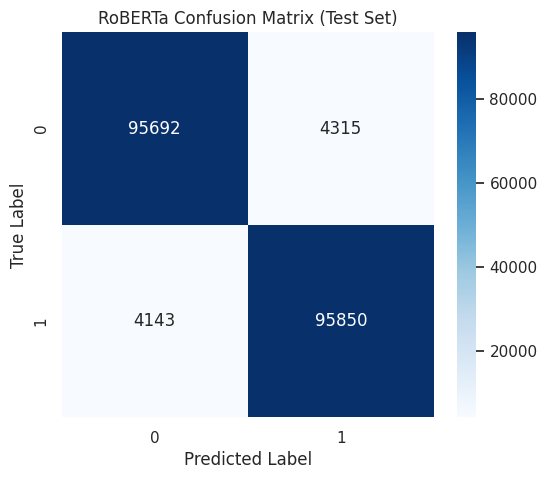

In [ ]:
cm_roberta = confusion_matrix(test_labels, roberta_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm_roberta, annot=True, fmt="d", cmap="Blues")
plt.title("RoBERTa Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 8.3.3 ROC Curve (RoBERTa)

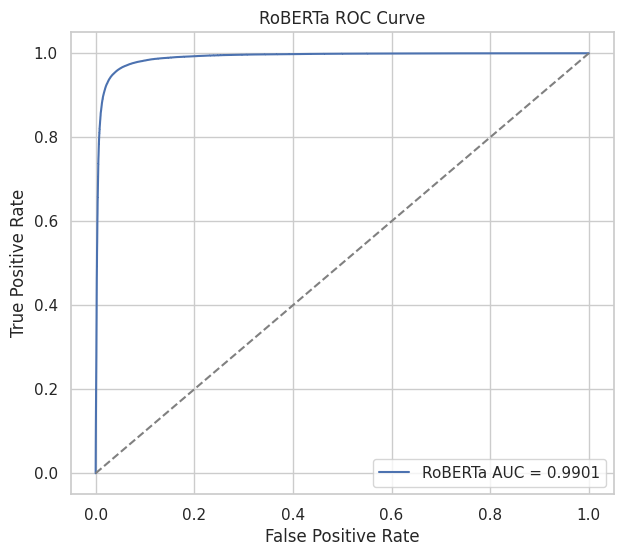

RoBERTa AUC: 0.9901341092516571


In [ ]:
probs_rb = torch.nn.functional.softmax(torch.tensor(logits_rb), dim=1).numpy()
roberta_prob_pos = probs_rb[:, 1]  # probability of class 1 (positive)

fpr_rb, tpr_rb, thresholds_rb = roc_curve(test_labels, roberta_prob_pos)
roc_auc_rb = auc(fpr_rb, tpr_rb)

plt.figure(figsize=(7,6))
plt.plot(fpr_rb, tpr_rb, label=f"RoBERTa AUC = {roc_auc_rb:.4f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RoBERTa ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("RoBERTa AUC:", roc_auc_rb)

## 8.4 Visualization of RoBERTa Feature Space

Just as we examined DistilBERT’s internal representations, we now analyze how
RoBERTa embeds review text into its learned feature space. RoBERTa is a
higher-capacity model than DistilBERT, so its feature space often exhibits
stronger separation between sentiment classes and more complex geometric
structure.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_roberta.to(device)
model_roberta.eval()

vis_n = 2000
vis_texts = test_texts[:vis_n]
vis_labels = np.array(test_labels[:vis_n])

# Tokenize in batches to avoid memory issues
batch_size = 64
all_embeddings_rb = []

with torch.no_grad():
    for i in range(0, vis_n, batch_size):
        batch_texts = vis_texts[i:i+batch_size]
        enc = roberta_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        ).to(device)

        hidden_states_rb = model_roberta.roberta(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"]
        ).last_hidden_state

        cls_embeddings_rb = hidden_states_rb[:, 0, :]
        all_embeddings_rb.append(cls_embeddings_rb.cpu())

# Stack all batches into one array
all_embeddings_rb = torch.cat(all_embeddings_rb, dim=0).numpy()
print(all_embeddings_rb.shape)



(2000, 768)


### 8.4.1 PCA Projection of RoBERTa Embeddings (Sentiment in 2D)

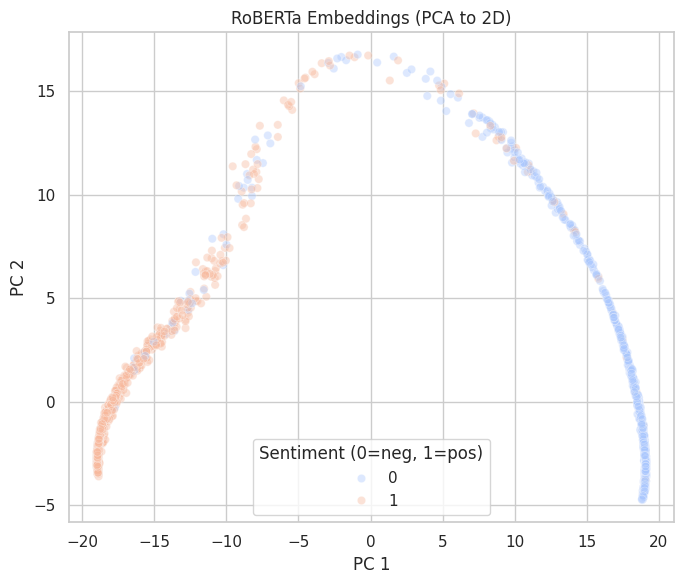

In [ ]:
# PCA to 2D
pca_rb = PCA(n_components=2, random_state=42)
emb_2d_rb = pca_rb.fit_transform(all_embeddings_rb)

plt.figure(figsize=(7,6))
sns.scatterplot(
    x=emb_2d_rb[:, 0],
    y=emb_2d_rb[:, 1],
    hue=vis_labels,
    palette="coolwarm",
    alpha=0.4
)
plt.title("RoBERTa Embeddings (PCA to 2D)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Sentiment (0=neg, 1=pos)")
plt.tight_layout()
plt.show()


RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


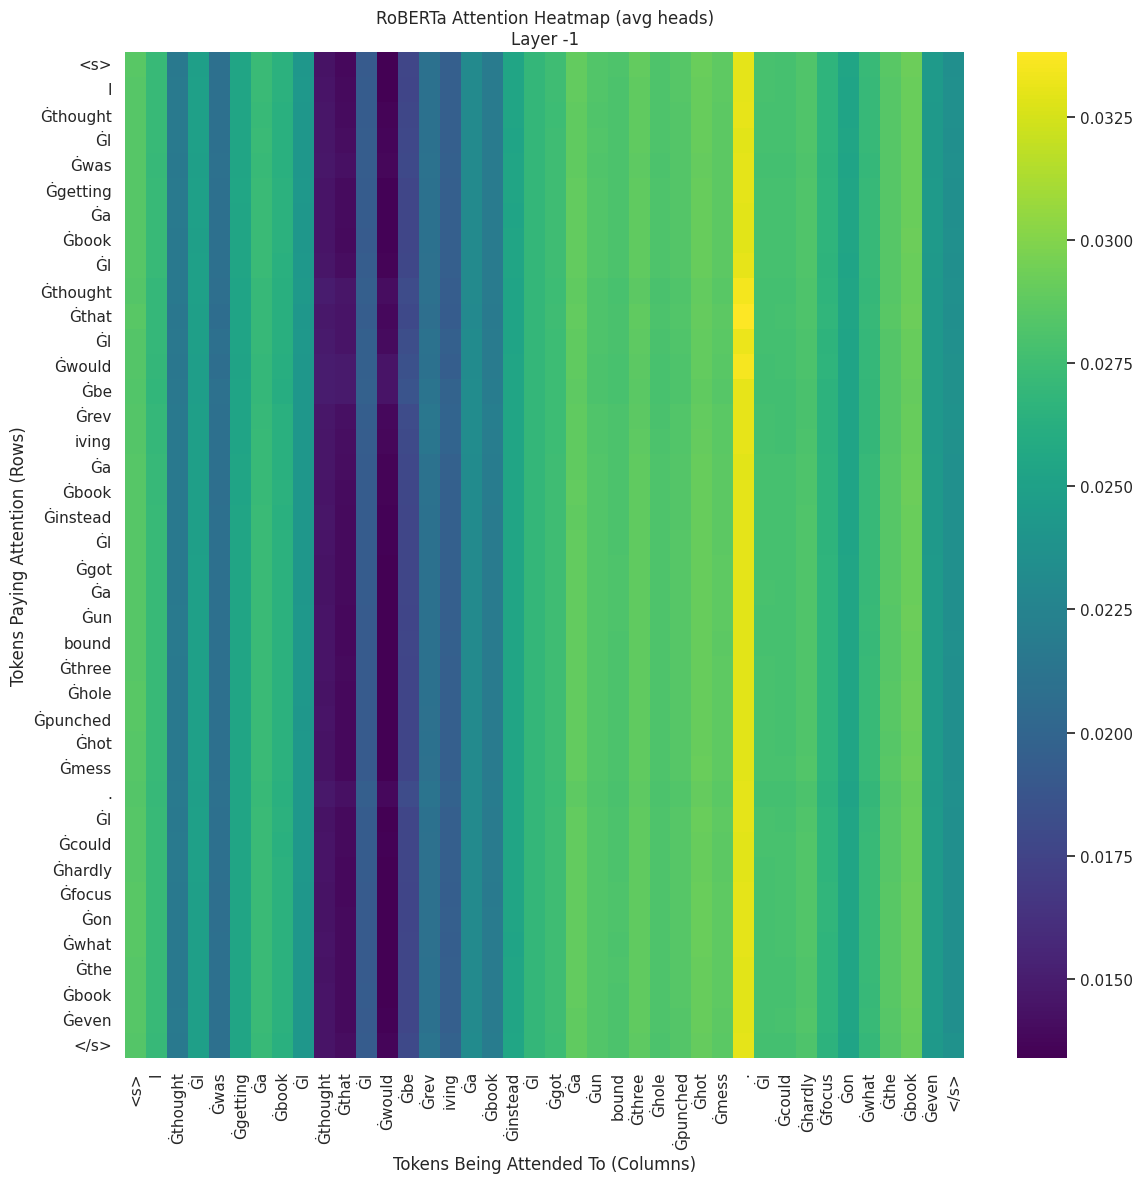

In [ ]:
# RoBERTa
plot_attention_heatmap(
    model=model_roberta,
    tokenizer=roberta_tokenizer,
    text=example_text,
    layer=-1,
    head=None,
    max_tokens=40,
    title_prefix="RoBERTa"
)

## 8.5 RoBERTa Performance Summary

RoBERTa outperforms both Logistic Regression and DistilBERT by a meaningful
margin. It handles complex linguistic phenomena, including long-range context,
subtle tone shifts, contrastive phrasing, and nuanced expressions of sentiment,
that simpler models struggle with.

- Sentiment clusters are **more sharply separated**  
- Positive reviews occupy a coherent region of the embedding space  
- Negative reviews form a symmetric but distinct region  
- Overlap occurs mainly for ambiguous or mixed-toned reviews  

## 9. Comparison of Models

We evaluate three sentiment classification models that represent different stages
in the evolution of pattern recognition in NLP: a traditional linear classifier,
a lightweight Transformer, and a larger pre-trained language model.

| Model                 | Training Size | Accuracy | F1 Score | AUC    | Notes |
|----------------------|--------------|----------|----------|--------|-------|
| Logistic Regression  | 1.44M        | 0.906    | 0.910    | 0.967  | Fast, simple baseline using TF-IDF features |
| DistilBERT           | 100k         | 0.9472   | 0.9468   | 0.9868 | Learns semantic structure; far better generalization |
| RoBERTa              | 100k         | 0.9571   | 0.9570   | 0.9900 | Most accurate; strongest contextual reasoning |

Even though DistilBERT and RoBERTa were trained on only **100,000** labeled
reviews (~14× less data than Logistic Regression), both models surpass the
baseline by a significant margin.

RoBERTa achieves the best overall performance, with the highest accuracy,
precision-recall balance, and AUC, demonstrating its ability to capture nuanced
sentiment cues in natural language.


In [ ]:
#Logisitic Regression
from sklearn.metrics import precision_recall_fscore_support

logreg_test_acc = accuracy_score(y_test, y_test_pred)
logreg_precision, logreg_recall, logreg_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average="binary"
)

print("LogReg Test accuracy:", logreg_test_acc)
print("LogReg Test F1:", logreg_f1)


LogReg Test accuracy: 0.90643
LogReg Test F1: 0.9068371217778309


In [ ]:
#DistillBERT

bert_test_acc = test_results["eval_accuracy"]
bert_test_f1  = test_results["eval_f1"]

print("BERT Test accuracy:", bert_test_acc)
print("BERT Test F1:", bert_test_f1)


BERT Test accuracy: 0.94702
BERT Test F1: 0.9466749871669703


In [ ]:
#RoBERTa

roberta_test_acc = test_results_rb["eval_accuracy"]
roberta_test_f1  = test_results_rb["eval_f1"]

print("RoBERTa Test accuracy:", roberta_test_acc)
print("RoBERTa Test F1:", roberta_test_f1)

RoBERTa Test accuracy: 0.95771
RoBERTa Test F1: 0.9577433827276451


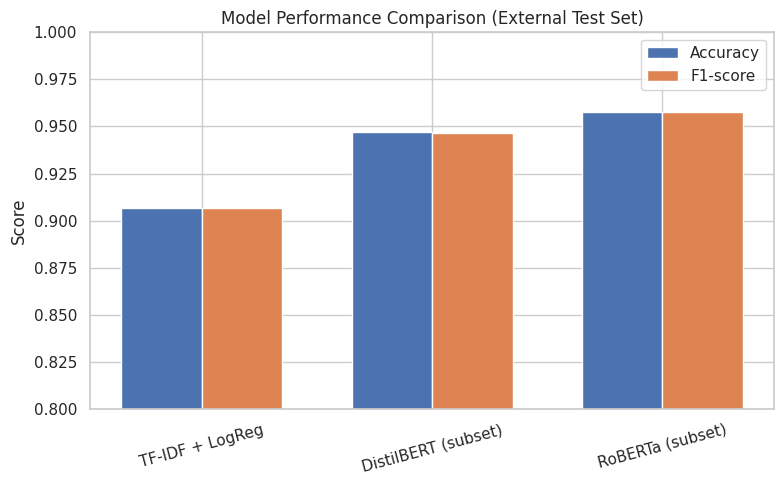

In [ ]:
#Comparison

models = ["TF-IDF + LogReg", "DistilBERT (subset)", "RoBERTa (subset)"]

accuracies = [
    logreg_test_acc,
    bert_test_acc,
    roberta_test_acc
]

f1_scores = [
    logreg_f1,
    bert_test_f1,
    roberta_test_f1
]

plt.figure(figsize=(8,5))
x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, accuracies, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="F1-score")

plt.xticks(x, models, rotation=15)
plt.ylim(0.80, 1.0)
plt.ylabel("Score")
plt.title("Model Performance Comparison (External Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Conclusion

This project examined sentiment analysis on a large-scale Amazon review dataset
(~1.8M reviews) using classical feature-based models and modern Transformer-based
architectures. The goal was to understand how model capacity, feature
representation, and learned language structure influence sentiment prediction.

### Key Observations

- **TF-IDF + Logistic Regression** performs strongly for a simple model
  (~90% accuracy), showing that linear classifiers remain competitive on well-separated text tasks.
  
- **Feature importance analysis** reveals clear sentiment markers such as
  “excellent”, “waste”, “poor”, and “highly recommended”.

- **Topic modeling** shows that both positive and negative reviews broadly cover similar product domains (books, movies, electronics), highlighting that *topic* is not a reliable sentiment signal, reinforcing the need for semantic models.

- **Error analysis + LIME** exposes the weaknesses of linear models for cases containing sarcasm, ambiguity, or mixed sentiment.

- **DistilBERT** provides a substantial boost in accuracy (94.7%) and AUC (~0.986), capturing deep contextual structure unavailable to sparse models.

- **RoBERTa** achieves the strongest performance overall (95.7% accuracy, AUC ~ 0.990), offering the clearest decision boundaries and most robust generalization.

- **PCA projections of embeddings** show that Transformers develop sentiment-sensitive latent spaces, unlike the TF-IDF representation.

### Final Takeaway

This project illustrates the broader shift in pattern recognition for NLP:
from manual feature engineering toward end-to-end representation learning.  
While traditional models remain fast and interpretable, Transformer models ,
even when trained on a small fraction of the data, deliver superior accuracy,
handle subtle linguistic cues, and learn richer internal structures that map
directly onto sentiment categories.

In practical terms, **RoBERTa provides the best overall balance of accuracy,
feature learning, and robustness**, making it the preferred model for large-scale
review classification.


## Future Work

There are several meaningful extensions that could further improve model
performance, interpretability, and generalization:

1. **Train for more epochs**.

2. **Use the full Amazon dataset**

3. **Experiment with larger Transformer variants**
   - Models such as DeBERTa, or ALBERT
   
